# 🎆 Convolutions

## Horizontal Edge Filter with Stride 3

Shape with Stride 3: (22, 22)


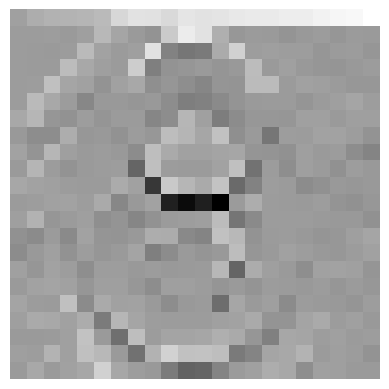

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

im = rgb2gray(data.coffee())
im = resize(im, (64, 64))
filter1 = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
stride = 3
# N = input size, F = filter size, P = padding, S = stride
# Output Size = ((N - F + 2P) / S) + 1
output_size_h = int(((im.shape[0] - 3 + 2 * 1) / stride) + 1)
output_size_w = int(((im.shape[1] - 3 + 2 * 1) / stride) + 1)
new_image_stride3_hor = np.zeros((output_size_h, output_size_w))
im_pad = np.pad(im, 1, "constant")
for i in range(0, im.shape[0], stride):
    for j in range(0, im.shape[1], stride):
        try:
            new_image_stride3_hor[int(i / stride), int(j / stride)] = (
                im_pad[i - 1, j - 1] * filter1[0, 0]
                + im_pad[i - 1, j] * filter1[0, 1]
                + im_pad[i - 1, j + 1] * filter1[0, 2]
                + im_pad[i, j - 1] * filter1[1, 0]
                + im_pad[i, j] * filter1[1, 1]
                + im_pad[i, j + 1] * filter1[1, 2]
                + im_pad[i + 1, j - 1] * filter1[2, 0]
                + im_pad[i + 1, j] * filter1[2, 1]
                + im_pad[i + 1, j + 1] * filter1[2, 2]
            )
        except:
            pass
plt.axis("off")
plt.imshow(new_image_stride3_hor, cmap="Greys")
print(f"Shape with Stride {stride}: {new_image_stride3_hor.shape}")

## Vertical Edge Filter with Stride 3

Shape with Stride 3: (22, 22)


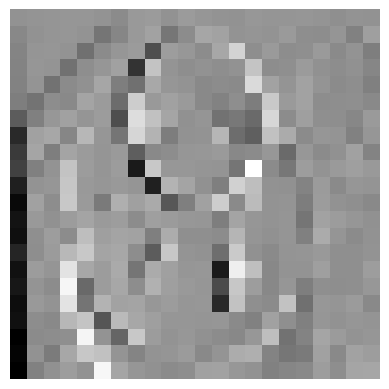

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

im = rgb2gray(data.coffee())
im = resize(im, (64, 64))

filter2 = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

stride = 3

# N = input size, F = filter size, P = padding, S = stride
# Output Size = ((N - F + 2P) / S) + 1
output_size_h = int(((im.shape[0] - 3 + 2 * 1) / stride) + 1)
output_size_w = int(((im.shape[1] - 3 + 2 * 1) / stride) + 1)
new_image_stride3_ver = np.zeros((output_size_h, output_size_w))

im_pad = np.pad(im, 1, "constant")

for i in range(0, im.shape[0], stride):
    for j in range(0, im.shape[1], stride):
        try:
            new_image_stride3_ver[int(i / stride), int(j / stride)] = (
                im_pad[i - 1, j - 1] * filter2[0, 0]
                + im_pad[i - 1, j] * filter2[0, 1]
                + im_pad[i - 1, j + 1] * filter2[0, 2]
                + im_pad[i, j - 1] * filter2[1, 0]
                + im_pad[i, j] * filter2[1, 1]
                + im_pad[i, j + 1] * filter2[1, 2]
                + im_pad[i + 1, j - 1] * filter2[2, 0]
                + im_pad[i + 1, j] * filter2[2, 1]
                + im_pad[i + 1, j + 1] * filter2[2, 2]
            )
        except:
            pass

plt.axis("off")
plt.imshow(new_image_stride3_ver, cmap="Greys")
print(f"Shape with Stride {stride}: {new_image_stride3_ver.shape}")

## Interpretation of Strides

In convolutional operations, the **stride** determines how many pixels the filter moves across the input image at each step. This has a direct impact on the size of the output image and the amount of detail retained.

*   **Stride 1 (Original Filter Application):**
    *   When the stride is 1 (as seen in the initial Horizontal and Vertical Edge Filter sections), the filter moves one pixel at a time, both horizontally and vertically. This results in an output image that is the same size as the input image (after accounting for padding).
    *   This preserves the most detail, as every possible convolution operation is performed, capturing all local features.

*   **Stride 2 (Horizontal/Vertical Edge Filter with Stride 2):**
    *   When the stride is 2, the filter skips one pixel for each move. This effectively downsamples the output image by a factor of 2 in both dimensions.
    *   The output image will be approximately half the width and half the height of the input. This reduces the computational cost and the number of parameters, but some fine-grained details might be lost.

*   **Stride 3 (Horizontal/Vertical Edge Filter with Stride 3 - demonstrated above):**
    *   With a stride of 3, the filter skips two pixels at each step. This leads to an even smaller output image, roughly one-third the width and height of the input.
    *   The downsampling is more aggressive, further reducing computational load and parameter count. However, it also means that more information from the original image is discarded, potentially leading to a coarser representation of features.

**Observations on Output and 'Accuracy':**

While

accuracy" is typically used in classification tasks, here we can interpret it in terms of how well the features (edges in this case) are represented and the overall clarity of the output image.

*   **Visual Clarity:** As the stride increases, the output images become smaller and appear more pixelated or

Visual clarity of features can be used as a qualitative evaluation of convolution results, while accuracy is usually measured when the CNN is used for classification.

In this notebook, we'll walk through how convolutional filters can pick out different aspects of an image

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

## 0. Original Input Image <a name="orig"></a>

In [ ]:
im = rgb2gray(data.coffee())
im = resize(im, (64, 64))
print(im.shape)

plt.axis("off")
plt.imshow(im, cmap="gray")

## Horizontal Edge Filter <a name="hor"></a>

In [ ]:
filter1 = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

new_image = np.zeros(im.shape)

im_pad = np.pad(im, 1, "constant")

for i in range(im.shape[0]):
    for j in range(im.shape[1]):
        try:
            new_image[i, j] = (
                im_pad[i - 1, j - 1] * filter1[0, 0]
                + im_pad[i - 1, j] * filter1[0, 1]
                + im_pad[i - 1, j + 1] * filter1[0, 2]
                + im_pad[i, j - 1] * filter1[1, 0]
                + im_pad[i, j] * filter1[1, 1]
                + im_pad[i, j + 1] * filter1[1, 2]
                + im_pad[i + 1, j - 1] * filter1[2, 0]
                + im_pad[i + 1, j] * filter1[2, 1]
                + im_pad[i + 1, j + 1] * filter1[2, 2]
            )
        except:
            pass

plt.axis("off")
plt.imshow(new_image, cmap="Greys")

## Vertical Edge Filter <a name="ver"></a>

In [ ]:
filter2 = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

new_image = np.zeros(im.shape)

im_pad = np.pad(im, 1, "constant")

for i in range(im.shape[0]):
    for j in range(im.shape[1]):
        try:
            new_image[i, j] = (
                im_pad[i - 1, j - 1] * filter2[0, 0]
                + im_pad[i - 1, j] * filter2[0, 1]
                + im_pad[i - 1, j + 1] * filter2[0, 2]
                + im_pad[i, j - 1] * filter2[1, 0]
                + im_pad[i, j] * filter2[1, 1]
                + im_pad[i, j + 1] * filter2[1, 2]
                + im_pad[i + 1, j - 1] * filter2[2, 0]
                + im_pad[i + 1, j] * filter2[2, 1]
                + im_pad[i + 1, j + 1] * filter2[2, 2]
            )
        except:
            pass

plt.axis("off")
plt.imshow(new_image, cmap="Greys")

## Horizontal Edge Filter with Stride 2 <a name="hor2"></a>

In [ ]:
filter1 = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

stride = 2

new_image = np.zeros((int(im.shape[0] / stride), int(im.shape[1] / stride)))

im_pad = np.pad(im, 1, "constant")

for i in range(0, im.shape[0], stride):
    for j in range(0, im.shape[1], stride):
        try:
            new_image[int(i / stride), int(j / stride)] = (
                im_pad[i - 1, j - 1] * filter1[0, 0]
                + im_pad[i - 1, j] * filter1[0, 1]
                + im_pad[i - 1, j + 1] * filter1[0, 2]
                + im_pad[i, j - 1] * filter1[1, 0]
                + im_pad[i, j] * filter1[1, 1]
                + im_pad[i, j + 1] * filter1[1, 2]
                + im_pad[i + 1, j - 1] * filter1[2, 0]
                + im_pad[i + 1, j] * filter1[2, 1]
                + im_pad[i + 1, j + 1] * filter1[2, 2]
            )
        except:
            pass

plt.axis("off")
plt.imshow(new_image, cmap="Greys")

## Vertical Edge Filter with Stride 2 <a name="ver2"></a>

In [ ]:
filter2 = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

stride = 2

new_image = np.zeros((int(im.shape[0] / stride), int(im.shape[1] / stride)))

im_pad = np.pad(im, 1, "constant")

for i in range(0, im.shape[0], stride):
    for j in range(0, im.shape[1], stride):
        try:
            new_image[int(i / stride), int(j / stride)] = (
                im_pad[i - 1, j - 1] * filter2[0, 0]
                + im_pad[i - 1, j] * filter2[0, 1]
                + im_pad[i - 1, j + 1] * filter2[0, 2]
                + im_pad[i, j - 1] * filter2[1, 0]
                + im_pad[i, j] * filter2[1, 1]
                + im_pad[i, j + 1] * filter2[1, 2]
                + im_pad[i + 1, j - 1] * filter2[2, 0]
                + im_pad[i + 1, j] * filter2[2, 1]
                + im_pad[i + 1, j + 1] * filter2[2, 2]
            )
        except:
            pass

plt.axis("off")
plt.imshow(new_image, cmap="Greys")